(253680, 22)
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  Income
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0                   0.0           0.0     0.0      1.0                0.0            1.0          0.0      5.0      18.0      15.0       1.0  0.0   9.0        4.0     3.0
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0                   0.0           1.0     0.0      0.0                0.0            0.0          1.0      3.0       0.0       0.0       0.0  0.0   7.0        6.0     1.0
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0                   0.0           0.0     1.0      0.0                0.0            1.0          1.0      5.0      30.0      30.0       1.0  0.0   9.0        4.0     8.0
3           0.0     1.0       0.0        1.

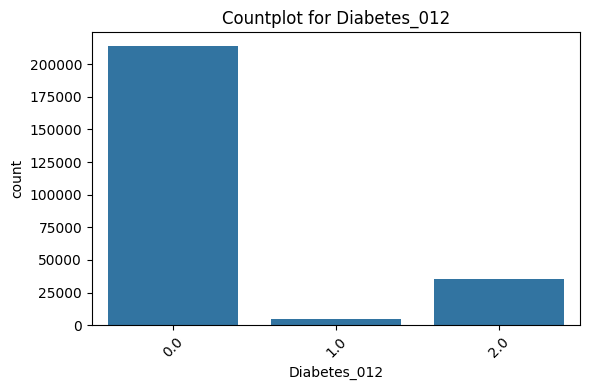

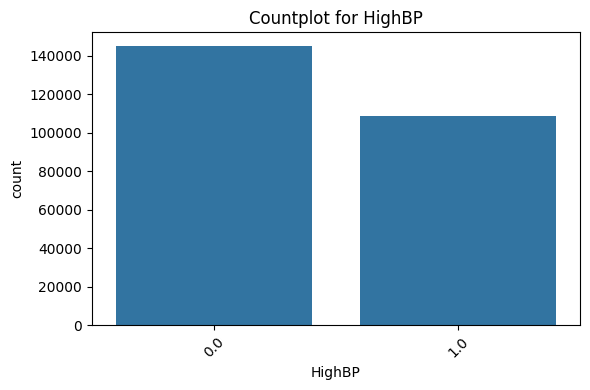

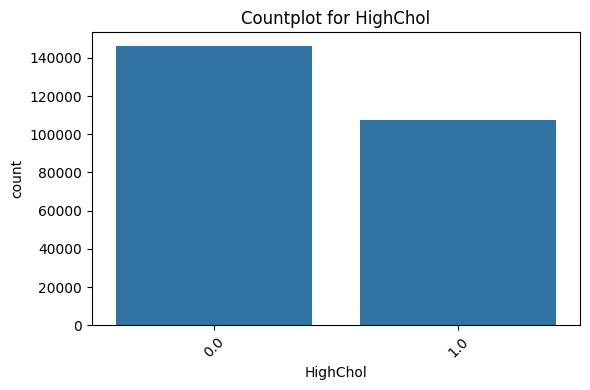

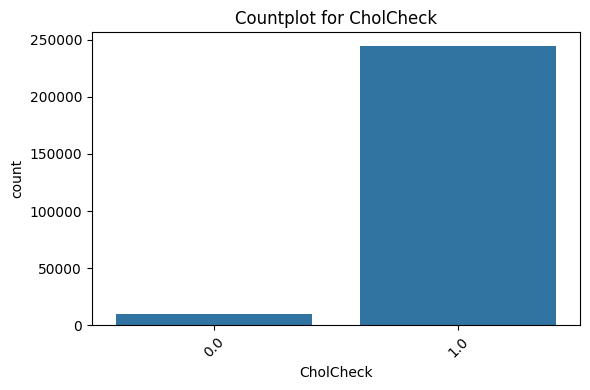

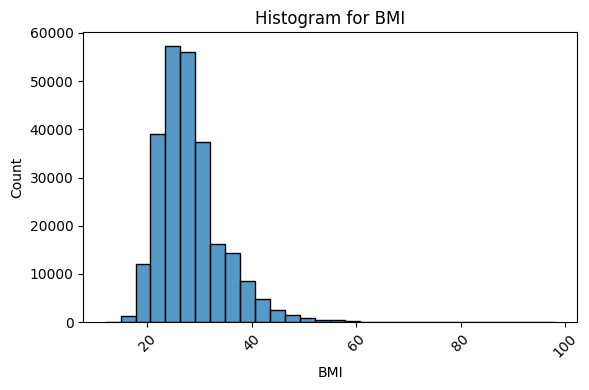

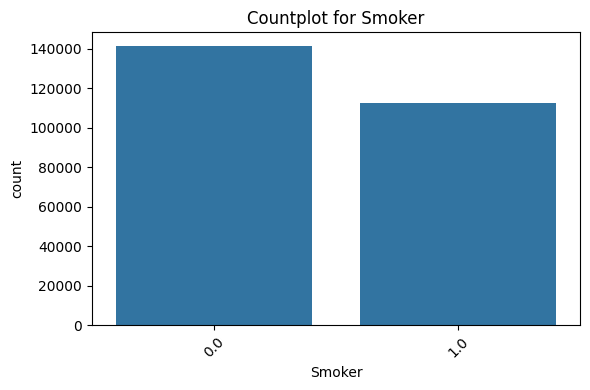

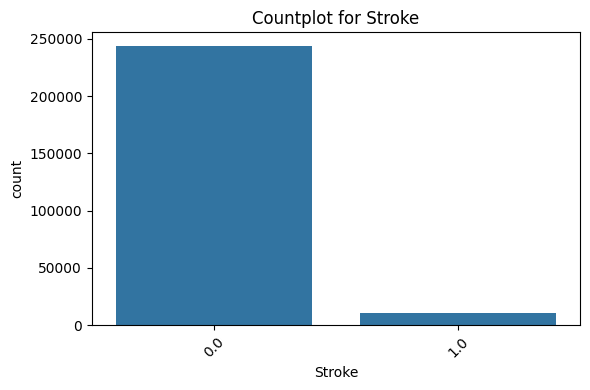

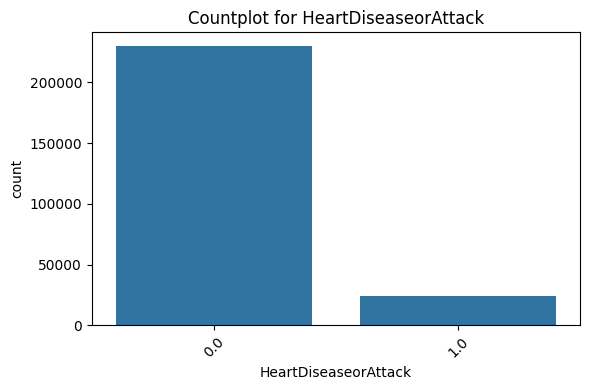

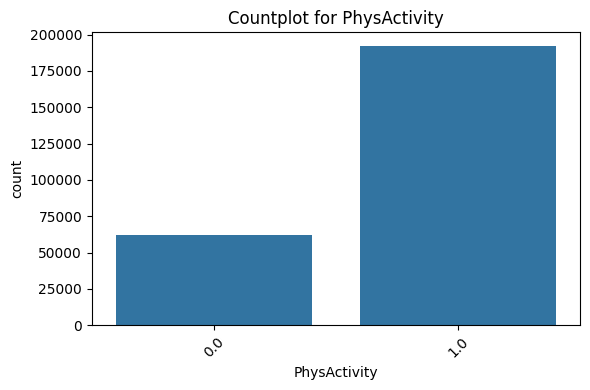

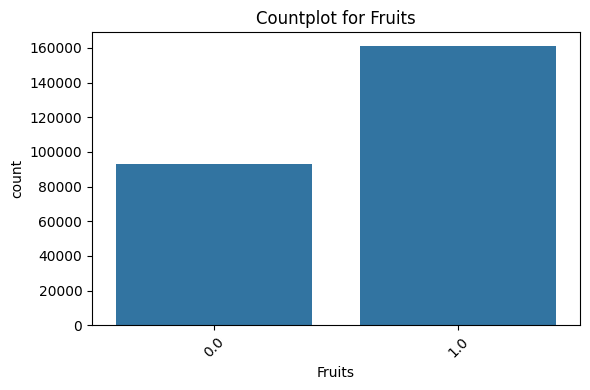

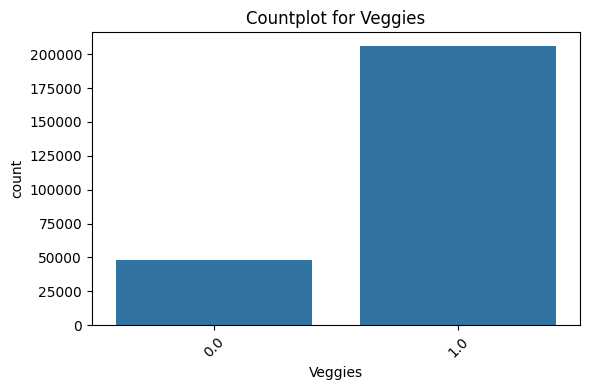

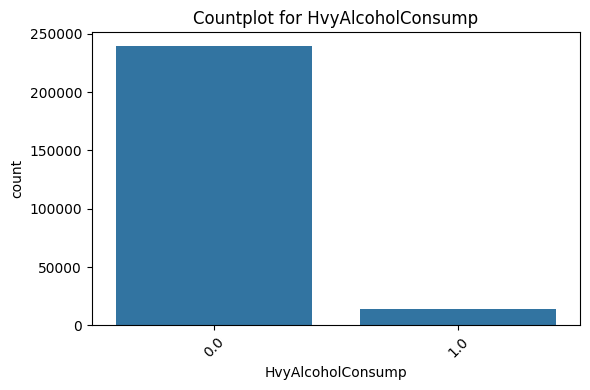

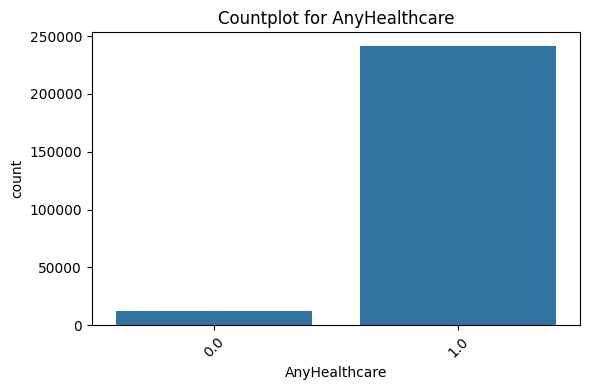

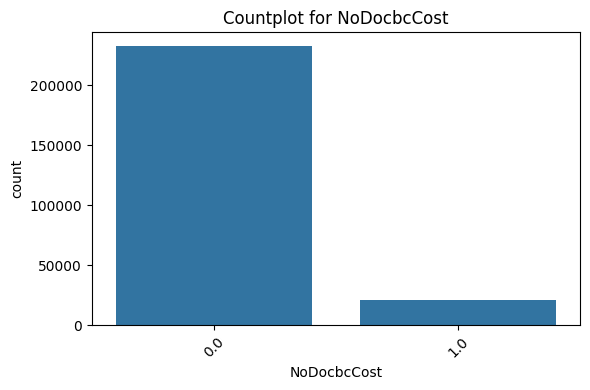

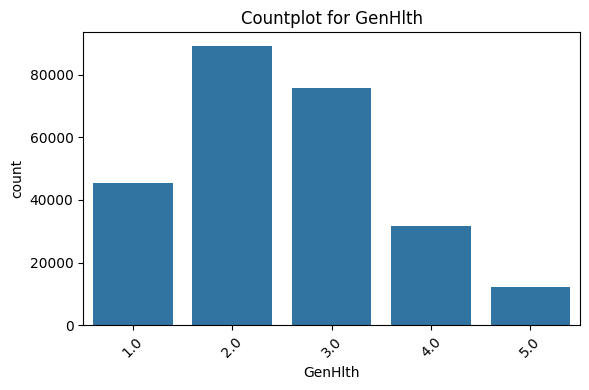

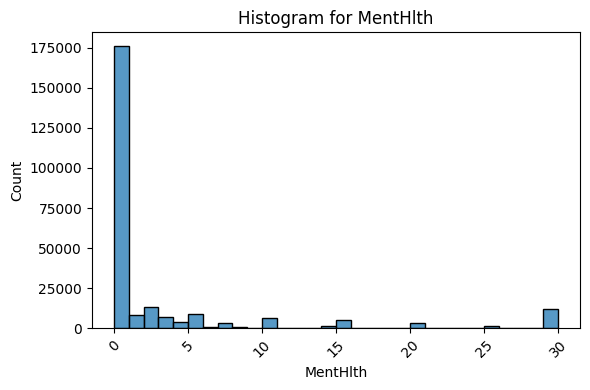

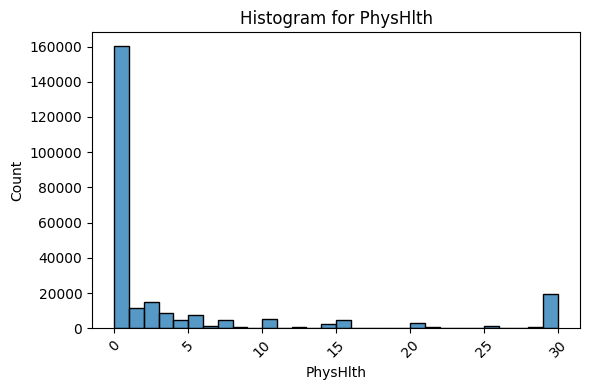

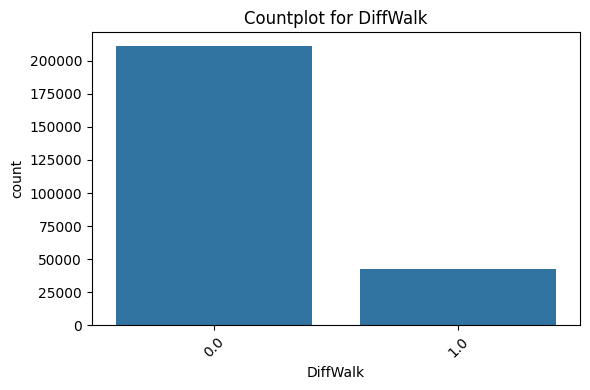

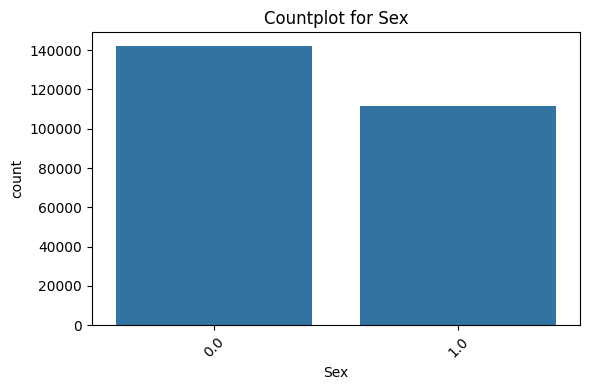

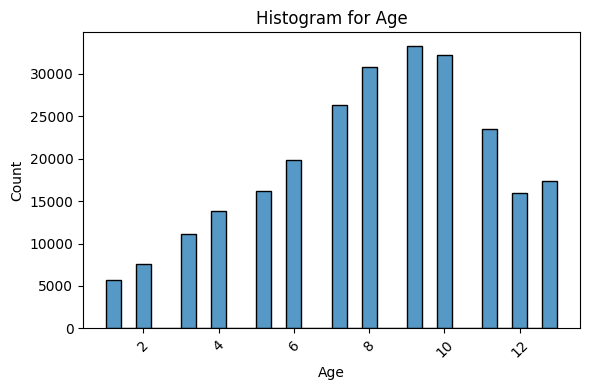

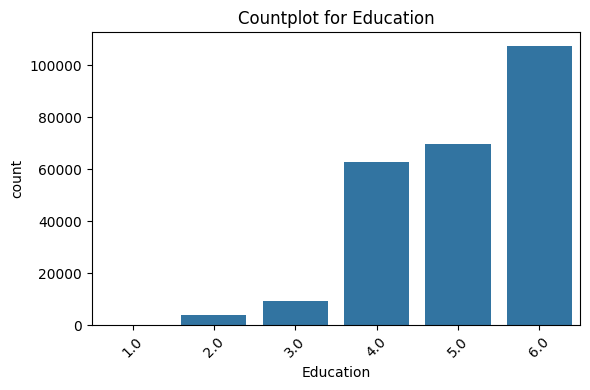

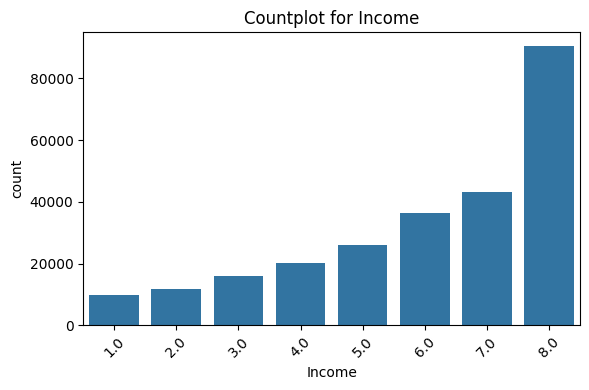

Diabetes_012 value counts:

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64


In [4]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

# Load the required CSV file 
df = pd.read_csv("diabetes.csv") 

# Set the display setting so that columns are shown across the screen and not truncated or split
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)

# Review the features to see what they look like and to perform an initial check of the distributions
print(df.shape)
print(df.head(10))

# Mean and median describe the central tendency of a dataset, helping analysts quickly understand its typical values. 
# Standard deviation captures how spread out the data is, which is essential for judging consistency and comparing groups. 
# Probability provides the mathematical language for uncertainty, allowing analysts to model randomness and estimate risks. 
# Hypothesis testing builds on probability to determine whether observed patterns are statistically meaningful rather than due to chance. 
# Together, these concepts form the foundation of data analysis because they enable clear summarization, rigorous inference, and evidence‑based decision‑making.

print(df.describe().T)
print(df.info())  # FIXED: added parentheses

# Reviewing the data types of each feature. All are floats! 
df.columns.to_list()
print("The datatypes are:\n", df.dtypes)

# Reviewing the unique values of each feature
print("The number of unique values is:\n",df.nunique().sort_values())

# Reviewing the level of null values. There are none!
print("The level of null values is:\n", df.isnull().sum())

# Show all of the columns in the diabetes dataset with their associated unique values for familarisation with the data file
for column in df.columns:
    print(f"\ncolumn: {column}")
    print(sorted(df[column].unique()))

# Exploratory Data Analysis (EDA) to relaly understand the data

# We will look at the distributions of all variables (as all are floats)
# Plot the data using bar charts / histograms as appropriate to understand the distributions
for col in df.columns:
    plt.figure(figsize=(6,4))

    # If the column is binary or categorical (few unique values)
    if df[col].nunique() <= 10:
        sns.countplot(data=df, x=col)
        plt.title(f"Countplot for {col}")
    
    # If the column is numeric with many unique values
    else:
        sns.histplot(data=df, x=col, bins=30, kde=False)
        plt.title(f"Histogram for {col}")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# It is important to Understand the counts for each of the 3 codes in Diabetes_012 (no diabetes, prediabetes and diabetes), the main Target in any analysis. For the total dataset 
# The counts are:
# No diabetes=213,703
# Prediabetes= 4,631
# Diabetes= 35,346
# So there is a significant class imbalance here that will need to be considered in any modelling work.

print("Diabetes_012 value counts:\n")
print(df["Diabetes_012"].value_counts())  # FIXED: added print


In [5]:
import sys
print(sys.executable)
import shap
print(shap.__version__)


c:\Users\teres\OneDrive\Capstone Project\Diabetes\.venv\Scripts\python.exe
0.49.1


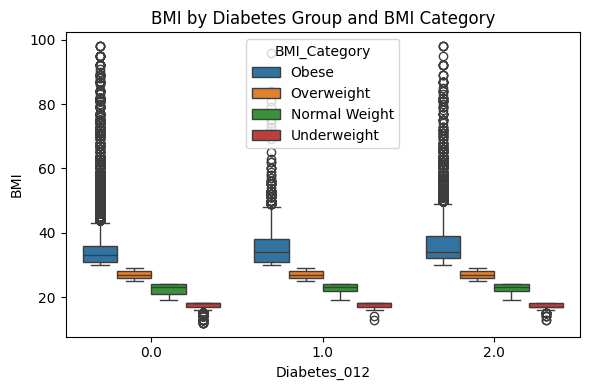

In [6]:
# Next, we will look at the relationship between BMI and Diabetes_012.
# The Describe showed that BMI has a mean of 28 and the BMI values ranges from 12 to 98!
# It should be noted that very high BMI values (e.g., >50) or very low values (e.g. < 18) are quite rare and may be outliers 
# or data entry errors.
# NB BMI values are self-reported and including extreme outliers is consistent with known limitations of large population health surveys.

import numpy as np

# For easier visualisation of BMI, BMI is banded into the standard BMI categories: 1: Underweight, 2: Normal weight, 3: Overweight, 4: Obese 
# The counts for each category are:
# BMI_Category
# Total: 253,680
# 1: Underweight:    31,273  
# 2: Normal weight:   68,953 
# 3: Overweight: 93,749
# 4: Obese: 87,851

# Define the conditions for BMI categories
conditions = [
    df["BMI"] <= 18.5,  # Underweight
    (df["BMI"] > 18.5) & (df["BMI"] <= 24.8),  # Normal Weight
    (df["BMI"] >= 25) & (df["BMI"] <= 29.9),  # Overweight
    df["BMI"] >= 30  # Obese
]

values = ["Underweight", "Normal Weight", "Overweight", "Obese"]

# Apply np.select to categorize BMI
df["BMI_Category"] = np.select(conditions, values, default="Unknown")

plt.figure(figsize=(6,4))
sns.boxplot(x='Diabetes_012', y='BMI', hue='BMI_Category', data=df)
plt.title("BMI by Diabetes Group and BMI Category")
plt.tight_layout()
plt.show()

# Findings
# From the boxplot, we can see that there is a trend of increasing BMI with increasing Diabetes_012 category. 
# This suggests that higher BMI is associated with a higher likelihood of diabetes.
# However some of the extreme BMI values may be distorting the picture. To further explore this relationship, 
# we can look at the mean BMI for each Diabetes_012 category.
df.groupby('Diabetes_012')['BMI'].mean().plot

In [7]:
# Dealing with the outliers in BMI is now considered. 
# Winsorize BMI at 1% and 99% percentiles to handle outliers
from scipy.stats.mstats import winsorize
df['BMI'] = winsorize(df['BMI'], limits=[0.01, 0.01])

# Winsorize BMI at 1% and 99% percentiles to handle outliers
from scipy.stats.mstats import winsorize
df['BMI'] = winsorize(df['BMI'], limits=[0.01, 0.01])

# Check the new BMI distribution
print("BMI statistics after winsorizing:")
print(df['BMI'].describe())
print(f"\nOriginal BMI range: {df['BMI'].min():.2f} - {df['BMI'].max():.2f}")

c:\Users\teres\OneDrive\Capstone Project\Diabetes\.venv\lib\site-packages\numpy\lib\function_base.py:4737: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\teres\OneDrive\Capstone Project\Diabetes\.venv\lib\site-packages\numpy\lib\function_base.py:4737: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\teres\OneDrive\Capstone Project\Diabetes\.venv\lib\site-packages\numpy\lib\function_base.py:4737: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


BMI statistics after winsorising:
count    253680.000000
mean         28.286246
std           6.032878
min          18.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          50.000000
Name: BMI_winsorised, dtype: float64

Winsorised BMI range: 18.00 - 50.00


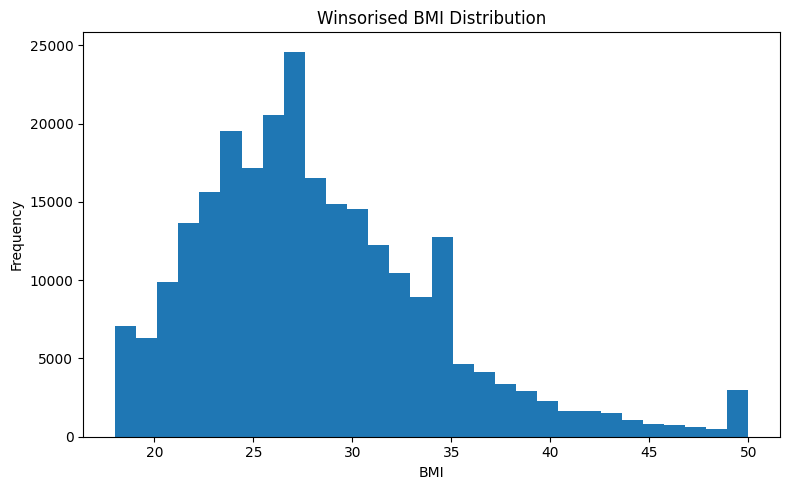


Saved cleaned dataset to diabetes_bmi_winsorised.csv


In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

# Winsorise BMI at 1% and 99% percentiles to handle outliers
lower = df['BMI'].quantile(0.01)
upper = df['BMI'].quantile(0.99)

# -----------------------------------------
# Create winsorised BMI column
# -----------------------------------------
df['BMI_winsorised'] = df['BMI'].clip(lower=lower, upper=upper)

# -----------------------------------------
# Verify winsorisation
# -----------------------------------------
print("BMI statistics after winsorising:")
print(df['BMI_winsorised'].describe())

print(
    f"\nWinsorised BMI range: "
    f"{df['BMI_winsorised'].min():.2f} - {df['BMI_winsorised'].max():.2f}"
)

# -----------------------------------------
# Plot histogram of winsorised BMI
# -----------------------------------------
ax = df['BMI_winsorised'].plot.hist(
    bins=30,
    title="Winsorised BMI Distribution",
    figsize=(8, 5)
)
ax.set_xlabel("BMI")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

df.to_csv("diabetes_bmi_winsorised.csv", index=False) 
print("\nSaved cleaned dataset to diabetes_bmi_winsorised.csv")

Columns in df_numeric: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'BMI_winsorised']
BMI_winsorised present: True


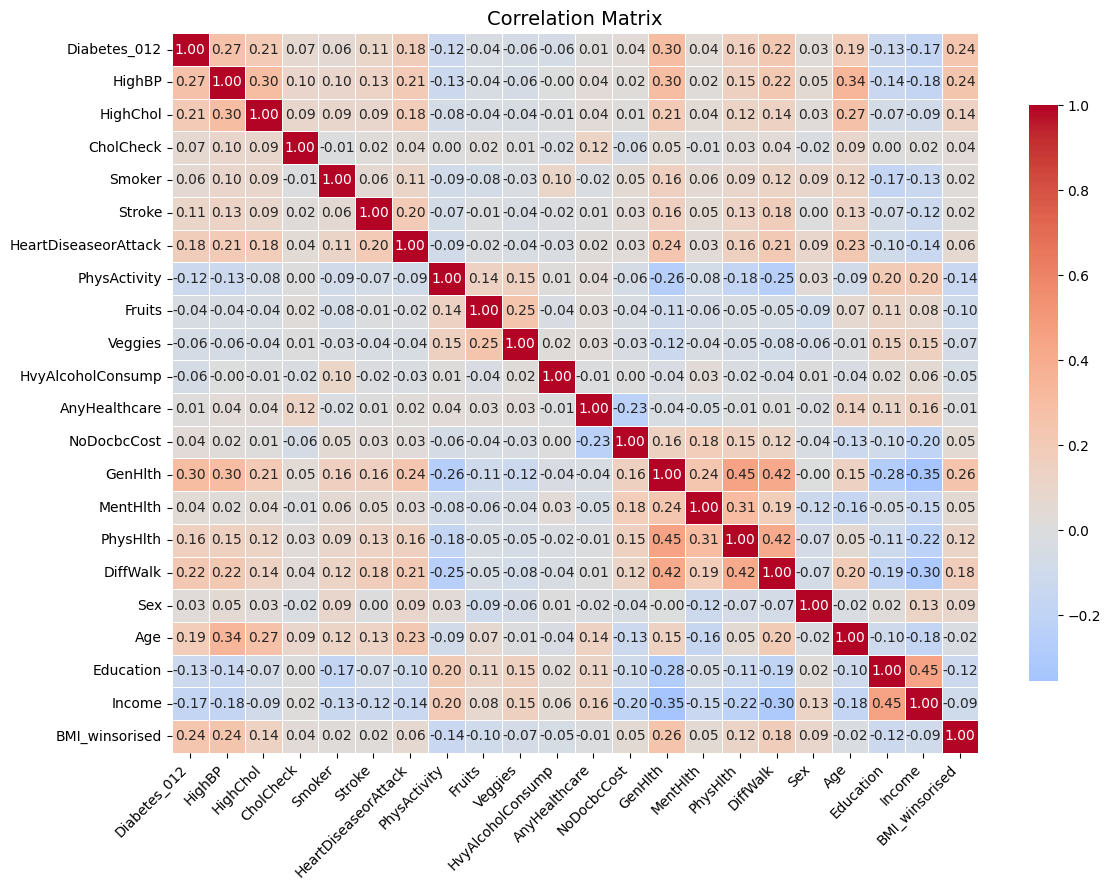


Correlation with Diabetes_012:
Diabetes_012            1.000000
GenHlth                 0.297138
HighBP                  0.271668
BMI_winsorised          0.235914
DiffWalk                0.223567
HighChol                0.210668
Age                     0.186357
HeartDiseaseorAttack    0.178564
PhysHlth                0.161718
Stroke                  0.105887
CholCheck               0.068018
Smoker                  0.063040
MentHlth                0.044921
NoDocbcCost             0.037379
Sex                     0.030143
AnyHealthcare           0.014530
Fruits                 -0.042268
HvyAlcoholConsump      -0.057244
Veggies                -0.059353
PhysActivity           -0.121988
Education              -0.126862
Income                 -0.172611
Name: Diabetes_012, dtype: float64


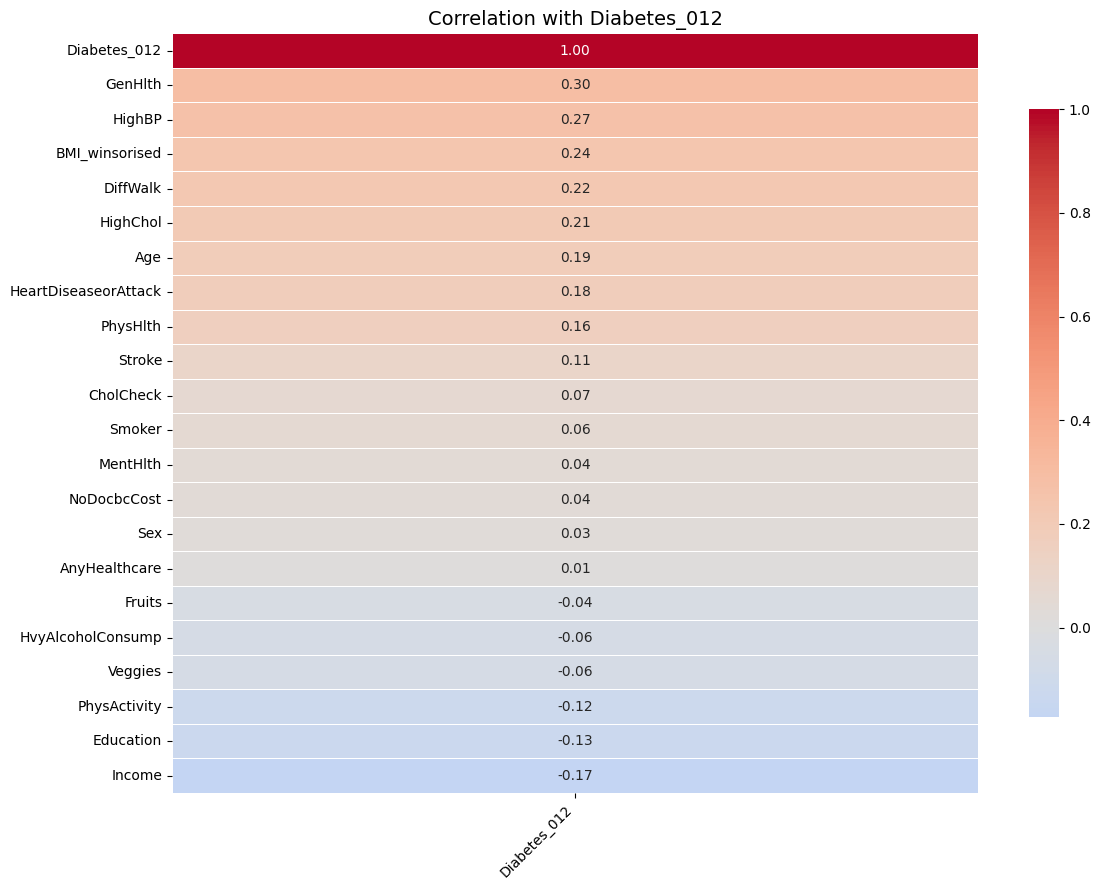

In [9]:
# Data Analysis

# A Spearman correlation, rather than a Pearson correlation, was selected to support the analysis as the distributions for the features are typically skewed 
# # (i.e. not normally distributed). 
# Two separate correlations were run:
# 1. An initial correlation of all features vs all features, to get an idea of the interplay between the features (heatmap)
# 2. A second correlation to focus on Diabetes_012 as the target variable versus all the other features. 

# Findings
#  1. This initial correlation matrix shows how health and demographic variables are interrelated. General health is linked to physical health and mobility issues, 
#  while age is correlated with higher blood pressure and poorer overall health. A higher BMI is associated with increased cardiovascular risks, and lower income and 
#  education levels tend to be associated with worse health outcomes. 
#  2. Diabetes risk is driven most strongly by overall health, blood pressure, BMI, mobility limitations, and cholesterol, with age and heart disease also playing meaningful roles. 
#  Protective factors like physical activity, higher education, and higher income show a lower likelihood of diabetes risk.


# Select numeric columns
df_numeric = df.select_dtypes(include=[np.number]).copy()

# Drop raw BMI and BMI category code, keep BMI_winsorised
cols_to_drop = ['BMI_Category_Code', 'BMI']
df_numeric = df_numeric.drop(columns=[c for c in cols_to_drop if c in df_numeric.columns])

# Verify BMI_winsorised andnot BMI is present as BMI is a key variable
print("Columns in df_numeric:", df_numeric.columns.tolist())
print("BMI_winsorised present:", 'BMI_winsorised' in df_numeric.columns)

# Correlation matrix
corr_matrix = df_numeric.corr(method="spearman")

# Create a heatmap to understand the relationships
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Second correlation this time with Diabetes_012 as the target to focus in on key drivers of diabetes risk
df_numeric_with_target = df_numeric.copy()
df_numeric_with_target['Diabetes_012'] = df['Diabetes_012']

corr_target = (
    df_numeric_with_target
    .corr(method="spearman")['Diabetes_012']
    .sort_values(ascending=False)
)

print("\nCorrelation with Diabetes_012:")
print(corr_target)

# Heatmap for Diabetes_012 as the target correlation
corr_df = corr_target.to_frame()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation with Diabetes_012", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()




In [10]:
# Chi Sqaure for all of the binary variables. Review  the Cramers_V score.
# Results Summary: 
# Once again, Diabetes risk is driven most strongly by overall health, blood pressure, BMI, mobility limitations, and cholesterol, with age and 
# heart disease also playing meaningful roles. Protective factors like physical activity, higher education, and higher income show a lower likelihood of diabetes risk.

# Strongest predictors      
# HighBP (V=0.272): Moderate, clinically meaningful
# DiffWalk (V=0.224): Moderate, clinically meaningful
# HighChol (V=0.211): Moderate, clinically meaningful

# Weaker but still relevant predictors
# HeartDiseaseorAttack(V=0.180): Weak but still clinically meaningful
# PhysActivity (V=0.122): Weak but still clinically meaningful
# Stroke (V=0.107): Weak but still clinically meaningful



In [11]:
# AI Assistant was used to help generate the code below for the Chi-square analysis.

# Chi-square to look at the relationship between the binary variables and Diabetes_012
# Chi-square tests were undertaken for the 14 binary variables, with Diabetes_012 as the target variable. 
# Findings
# The chi-square results show that all 14 variables have statistically significant associations with 
# diabetes status, but the strength of those relationships varies widely. 
# High blood pressure, difficulty walking, high cholesterol, and heart disease/attack exhibit the strongest
# associations (highest Cramer's V), suggesting they are the most influential correlates of diabetes in 
# this set. 
# Whereas, variables such as sex and (lack of) access to healthcare show very weak associations, indicating
# they have a minimal practical relationship despite statistical significance driven by the large sample size.

# Chi-square tests for specified binary variables vs Diabetes_012 — combined summary table
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# 14 binary variables to test
binary_vars = [
    'HighBP',
    'HighChol',
    'CholCheck',
    'Stroke',
    'HeartDiseaseorAttack',
    'PhysActivity',
    'Smoker',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'Sex',
    'DiffWalk',
    'AnyHealthcare',
    'NoDocbcCost'
 ]
labels = sorted(df['Diabetes_012'].dropna().unique())

# Function to calculate Cramer's V (which in this instance may be more important than phi coefficient)
def cramers_v(confusion_matrix):
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)
    n = confusion_matrix.values.sum()
    r, k = confusion_matrix.shape
    if n == 0 or min(r-1, k-1) == 0:
        return np.nan
    return np.sqrt(chi2 / (n * min(r-1, k-1)))

# Store results
results = []
print('Computing chi-square and Cramer\'s V for binary variables vs Diabetes_012...\n')
for var in binary_vars:
    if var not in df.columns:
        print(f"{var}: NOT IN DATA -- skipping\n")
        continue
    ct = pd.crosstab(df[var], df['Diabetes_012'])
    if ct.size == 0:
        print(f"{var}: empty crosstab -- skipping\n")
        continue
    try:
        chi2, p, dof, expected = chi2_contingency(ct)
        cv = cramers_v(ct)
        # counts of 'positive' (value==1) per Diabetes_012 group when applicable
        row = {'variable': var, 'chi2': chi2, 'p': p, 'dof': dof, 'cramers_v': cv}
        is_binary_one = df[var].isin([1]).any()
        for lbl in labels:
            col_name = f'pos_count_{int(lbl)}'
            if is_binary_one:
                cnt = int(df.loc[(df[var] == 1) & (df['Diabetes_012'] == lbl)].shape[0])
            else:
                cnt = np.nan
            row[col_name] = cnt
        results.append(row)
    except Exception as e:
        print(f"Error testing {var}: {e}\n")

# Build a summary dataframe
if results:
    res_df = pd.DataFrame(results)
    # ensure pos_count columns appear in order 0,1,2 if present
    pos_cols = [c for c in res_df.columns if c.startswith('pos_count_')]
    ordered_cols = ['variable', 'chi2', 'p', 'dof', 'cramers_v'] + sorted(pos_cols)
    res_df = res_df[ordered_cols]
    res_df = res_df.sort_values('cramers_v', ascending=False).reset_index(drop=True)
    print('Summary table (sorted by Cramer\'s V):')
    display(res_df)
else:
    print('No results to display')

Computing chi-square and Cramer's V for binary variables vs Diabetes_012...

Summary table (sorted by Cramer's V):


,variable,chi2,p,dof,cramers_v,pos_count_0,pos_count_1,pos_count_2
0,HighBP,18794.644052,0.000000e+00,2,0.272191,79312,2913,26604
1,DiffWalk,12776.941889,0.000000e+00,2,0.224425,28269,1285,13121
2,HighChol,11258.920399,0.000000e+00,2,0.210671,81030,2875,23686
3,HeartDiseaseorAttack,8244.889107,0.000000e+00,2,0.180281,15351,664,7878
4,PhysActivity,3789.301463,0.000000e+00,2,0.122218,166491,3142,22287
5,Stroke,2916.751980,0.000000e+00,2,0.107228,6759,265,3268
6,CholCheck,1173.749358,1.329124e-255,2,0.068021,204536,4569,35105
7,Smoker,1010.511751,3.716732e-220,2,0.063114,91824,2282,18317
8,Veggies,893.841905,8.029646e-195,2,0.059359,175544,3561,26736
9,HvyAlcoholConsump,850.324048,2.261930e-185,2,0.057896,13216,208,832


# Time for Modelling: Multinomial Logistic Regression First - using AI Agent and modified by the data analyst


Accuracy: 0.6902

Classification report:
               precision    recall  f1-score   support

           0     0.9449    0.7050    0.8075     42741
           1     0.0349    0.1825    0.0586       926
           2     0.3367    0.6670    0.4475      7069

    accuracy                         0.6902     50736
   macro avg     0.4388    0.5182    0.4379     50736
weighted avg     0.8435    0.6902    0.7437     50736



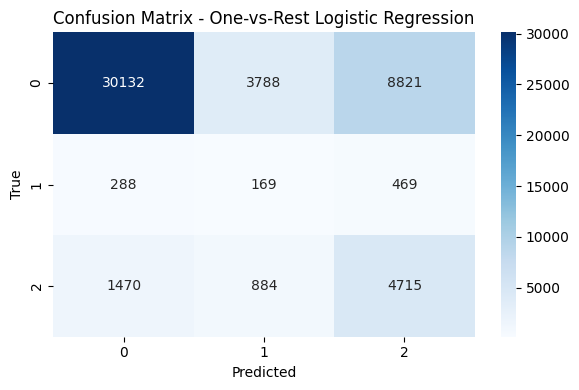


Top positive/negative coefficients per class:

class_0 - top positive features:
 HvyAlcoholConsump    0.145476
Income               0.133811
PhysHlth             0.055253
Education            0.042428
Fruits               0.024260
PhysActivity         0.016297
MentHlth             0.015884
Veggies              0.011947
Name: class_0, dtype: float64
class_0 - top negative features:
 GenHlth                -0.586106
BMI_winsorised         -0.503887
Age                    -0.467090
HighBP                 -0.333713
HighChol               -0.293198
CholCheck              -0.229397
Sex                    -0.128279
HeartDiseaseorAttack   -0.066735
Name: class_0, dtype: float64

class_1 - top positive features:
 Age               0.389997
BMI_winsorised    0.310491
GenHlth           0.264764
HighChol          0.243062
CholCheck         0.123667
HighBP            0.122608
NoDocbcCost       0.099772
MentHlth          0.066170
Name: class_1, dtype: float64
class_1 - top negative features:
 Incom

In [12]:
# Multinomial Logistic regression using AI Agent with editing from data analyst!
# Findings Summary: 
# Despite achieving moderate overall accuracy (69%), the multinomial logistic regression performs poorly on the two minority classes, 
# especially prediabetes, indicating a limited ability to differentiate between the three diabetes classes.
# Individuals who are younger, leaner, healthier, and socioeconomically advantaged are much more likely to be classified as having no diabetes.

# Confusion Matrix analysis shows that:
# No diabetes (class 0) shows that whilst most predictions are correctly identified (30,130), a further 12,611 are misclassified, especially 
# diabetes (class 2). Furthermore, prediabetes (class 1) shows very poor performance with only 169 out of 926 cases correctly identified. 
# Most are misclassified as diabetes (class 2). Finally, diabetes (class 2) shows moderate performance with 4,716 correct predictions out of 
# 7,069, but with 1,470 misclassified as no diabetes (class 0).
# In summary, the model over-predicts diabetes and misclassifies a substantial number of diabetes cases as healthy. 
# This limits its usefulness in a medical setting.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("diabetes_bmi_winsorised.csv")

# Select numeric features
X = df.select_dtypes(include=[np.number]).copy()

# Drop target
if 'Diabetes_012' in X.columns:
    X = X.drop(columns=['Diabetes_012'])

# Drop raw BMI and category code, keep BMI_winsorised
cols_to_drop = ['BMI', 'BMI_Category_Code']
X = X.drop(columns=[c for c in cols_to_drop if c in X.columns])

# Target
y = df['Diabetes_012'].astype(int)


# -----------------------
# Train/test split
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------
# Scale features
# -----------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# -----------------------
# One-vs-Rest Logistic Regression
# -----------------------
base = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf = OneVsRestClassifier(base)   # OVR wrapper
clf.fit(X_train_s, y_train)

# Predict
y_pred = clf.predict(X_test_s)

# -----------------------
# Metrics
# -----------------------
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - One-vs-Rest Logistic Regression')
plt.tight_layout()
plt.show()

# -----------------------
# Coefficients per class
# -----------------------
coef_mat = np.vstack([est.coef_.ravel() for est in clf.estimators_])  # shape (n_classes, n_features)
coef_df = pd.DataFrame(coef_mat.T, index=X.columns, columns=[f'class_{c}' for c in clf.classes_])

print("\nTop positive/negative coefficients per class:")
for c in coef_df.columns:
    top_pos = coef_df[c].sort_values(ascending=False).head(8)
    top_neg = coef_df[c].sort_values().head(8)
    print(f"\n{c} - top positive features:\n", top_pos)
    print(f"{c} - top negative features:\n", top_neg)



Prediabetes vs Diabetes binary class distribution:
Diabetes_012
0    35346
1     4631
Name: count, dtype: int64

Accuracy: 0.5933
ROC AUC: 0.6241

Classification report:
              precision    recall  f1-score   support

           0     0.9154    0.5950    0.7212      7070
           1     0.1579    0.5799    0.2483       926

    accuracy                         0.5933      7996
   macro avg     0.5367    0.5875    0.4848      7996
weighted avg     0.8276    0.5933    0.6665      7996



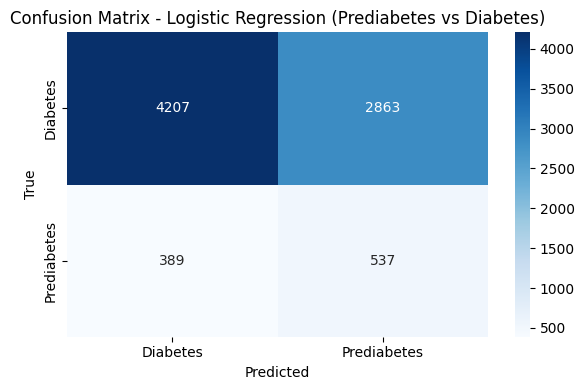


Top positive coefficients (Prediabetes):
NoDocbcCost          0.096724
HvyAlcoholConsump    0.095694
MentHlth             0.090142
PhysActivity         0.020616
PhysHlth             0.012295
Fruits               0.011037
Income              -0.001253
Smoker              -0.013106
Veggies             -0.022717
AnyHealthcare       -0.023978
dtype: float64

Top negative coefficients (Prediabetes):
HighChol               -0.032736
Education              -0.037378
Age                    -0.048035
DiffWalk               -0.056441
Sex                    -0.077500
Stroke                 -0.080507
HeartDiseaseorAttack   -0.114275
BMI_winsorised         -0.130629
HighBP                 -0.166288
GenHlth                -0.283191
dtype: float64


In [13]:
# Due to the class imbalance of no diabetes, I am rerunning as a binary Logistic Regression exclusively for Prediabetes (Code 1) vs Diabetes (Code 0) to see if we can get better separation.
# The aim is to understand the factors that lead from prediabetes to diabetes. 

# Findings
# This logistic regression comparing prediabetes with diabetes showed limited ability to distinguish between the two groups, achieving only moderate performance (ROC AUC = 0.62) 
# despite the large sample size. Indeed, the performance for identifying prediabetes was particularly weak, reflecting both the severe class imbalance and the close similarity 
# between the two metabolic states. 
# Overall, the available variables do not provide enough differentiation to reliably separate prediabetes from diabetes.
#
# Confusion Matrix analysis shows that:
# The model correctly identifies 4,206 out of 7,070 cases, but 2,864 are misclassified as prediabetes. 537 out of 926 cases are correctly predicted as prediabetes, 
# while 389 are misclassified as diabetes.
# The model could be useful for initial screening but lacks the precision required for a formal diagnosis.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

df = pd.read_csv("diabetes_bmi_winsorised.csv")

# -----------------------------------------
# Filter to prediabetes (1) vs diabetes (2)
# -----------------------------------------
df_prediabetes = df[df['Diabetes_012'].isin([1, 2])].copy()

# Binary target: 1 = prediabetes, 0 = diabetes
y_pred = (df_prediabetes['Diabetes_012'] == 1).astype(int)

# -----------------------------------------
# Select numeric features
# -----------------------------------------
X_pred = df_prediabetes.select_dtypes(include=[np.number]).copy()

# Drop target
X_pred = X_pred.drop(columns=['Diabetes_012'])

# Drop raw BMI and category code, keep BMI_winsorised
cols_to_drop = ['BMI', 'BMI_Category_Code']
X_pred = X_pred.drop(columns=[c for c in cols_to_drop if c in X_pred.columns])

print("Prediabetes vs Diabetes binary class distribution:")
print(y_pred.value_counts())

# -----------------------------------------
# Train/test split
# -----------------------------------------
X_train_pred, X_test_pred, y_train_pred, y_test_pred = train_test_split(
    X_pred, y_pred, test_size=0.2, stratify=y_pred, random_state=42
)

# -----------------------------------------
# Scale features
# -----------------------------------------
scaler_pred = StandardScaler()
X_train_pred_s = scaler_pred.fit_transform(X_train_pred)
X_test_pred_s = scaler_pred.transform(X_test_pred)

# -----------------------------------------
# Logistic Regression
# -----------------------------------------
lr_pred = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_pred.fit(X_train_pred_s, y_train_pred)

# Predict
y_pred_pred = lr_pred.predict(X_test_pred_s)
y_prob_pred = lr_pred.predict_proba(X_test_pred_s)[:, 1]

# -----------------------------------------
# Metrics
# -----------------------------------------
print(f"\nAccuracy: {accuracy_score(y_test_pred, y_pred_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test_pred, y_prob_pred):.4f}")
print("\nClassification report:")
print(classification_report(y_test_pred, y_pred_pred, digits=4))

# Confusion matrix
cm_pred = confusion_matrix(y_test_pred, y_pred_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_pred, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Diabetes', 'Prediabetes'], yticklabels=['Diabetes', 'Prediabetes'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Logistic Regression (Prediabetes vs Diabetes)')
plt.tight_layout()
plt.show()

# -----------------------------------------
# Coefficients
# -----------------------------------------
coef_pred = pd.Series(lr_pred.coef_[0], index=X_pred.columns).sort_values(ascending=False)

print("\nTop positive coefficients (Prediabetes):")
print(coef_pred.head(10))

print("\nTop negative coefficients (Prediabetes):")
print(coef_pred.tail(10))


In [14]:
# Random Forest using AI Agent with some minor tweaks.
# Random Forset is well suited to handle class imbalance and can provide feature importance metrics. Initially using default parameters i.e. no diabetes vs prediabetes vs diabetes.

# Findings:
# This model achieves an 84% accuracy, which is almost entirely driven by the no diabetes class i.e. the dominant class. It has extremely poor recall for prediabetes, in particular,
# as well as diabetes, which may be problematic in a real-world setting. 
# Feature importance is dominated by BMI, age, income, physical and general health, which are known diabetes risk factors
#
# Confusion Matrix analysis shows that:
# The model mostly correctly predicts no diabetes (41,441 predictions) but 1,300 cases are misclassified, mainly as diabetes (1,172 cases)
# The model completely misses the prediabetes class, mostly misclassifying as no diabetes (857 cases) which suggests that it may not be able to make a meaningful decision for this category.
# There is a diabetes underprediction, with the model heavily favouring predicting ‘no diabetes’, even for true diabetes cases (5,925 cases), which could be extremely problematic.
# A key reason for this is likely to be the imbalance in the dataset with the dominance of ‘no diabetes’ predictions, which may be skewing the model’s decision-making.
# 
# The model’s failure to reliably distinguish the high-risk groups means that it will have limited usefulness in a real-world setting.


Multiclass class distribution (0=No Diabetes, 1=Prediabetes, 2=Diabetes):
Diabetes_012
0    213703
2     35346
1      4631
Name: count, dtype: int64

Accuracy: 0.8390

Classification report:
              precision    recall  f1-score   support

           0     0.8594    0.9696    0.9112     42741
           1     0.0000    0.0000    0.0000       926
           2     0.4764    0.1597    0.2392      7069

    accuracy                         0.8390     50736
   macro avg     0.4452    0.3764    0.3835     50736
weighted avg     0.7903    0.8390    0.8009     50736



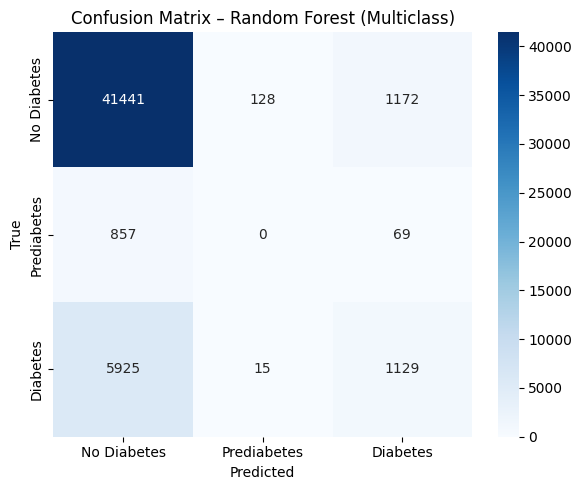


Top 15 Feature Importances:
BMI_winsorised    0.176090
Age               0.136864
Income            0.098828
PhysHlth          0.078618
GenHlth           0.071413
Education         0.068487
MentHlth          0.065723
Smoker            0.035564
Fruits            0.035047
HighBP            0.034379
Sex               0.033271
Veggies           0.027300
PhysActivity      0.027211
HighChol          0.026885
DiffWalk          0.018963
dtype: float64


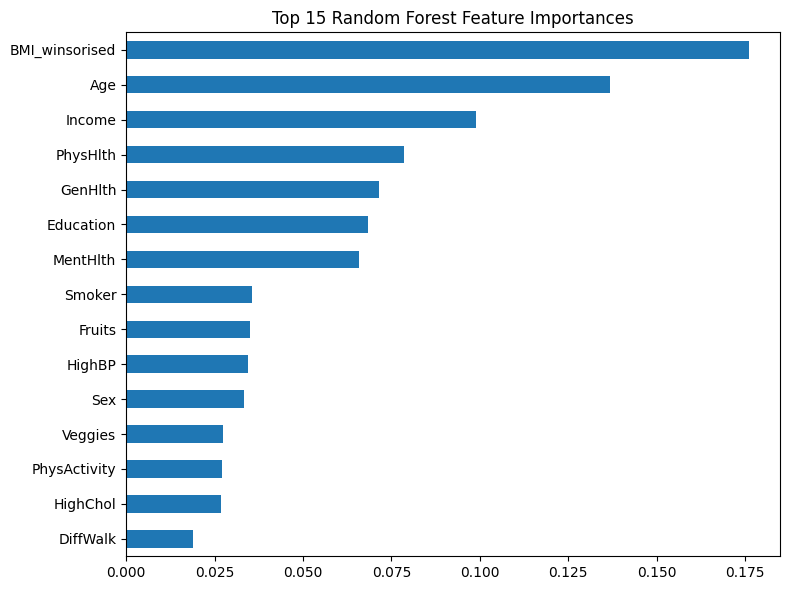

In [15]:
# Random Forest classifier (multiclass - no diabetes, prediabetes, diabetes) — train / evaluate / importances

import pandas as pd
import numpy as np

# Modeling
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------
# Load cleaned dataset
# -----------------------------------------
df = pd.read_csv("diabetes_bmi_winsorised.csv")

# Target
y = df["Diabetes_012"].astype(int)

print("Multiclass class distribution (0=No Diabetes, 1=Prediabetes, 2=Diabetes):")
print(y.value_counts())

# -----------------------------------------
# Prepare features (numeric only)
# -----------------------------------------
X = df.select_dtypes(include=["number"]).copy()

# Drop target
X = X.drop(columns=["Diabetes_012"])

# Drop raw BMI and BMI category code, keep BMI_winsorised
cols_to_drop = ["BMI", "BMI_Category_Code"]
X = X.drop(columns=[c for c in cols_to_drop if c in X.columns])

# -----------------------------------------
# Train/test split
# -----------------------------------------
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------------------------
# Random Forest
# -----------------------------------------
rf_mc = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_mc.fit(X_train_mc, y_train_mc)

# Predict
y_pred_mc = rf_mc.predict(X_test_mc)
y_prob_mc = rf_mc.predict_proba(X_test_mc)

# -----------------------------------------
# Metrics
# -----------------------------------------
print(f"\nAccuracy: {accuracy_score(y_test_mc, y_pred_mc):.4f}")
print("\nClassification report:")
print(classification_report(y_test_mc, y_pred_mc, digits=4))

# Confusion matrix
cm_mc = confusion_matrix(y_test_mc, y_pred_mc, labels=[0, 1, 2])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_mc, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Diabetes', 'Prediabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Prediabetes', 'Diabetes']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – Random Forest (Multiclass)')
plt.tight_layout()
plt.show()

# -----------------------------------------
# Feature importances
# -----------------------------------------
fi_mc = pd.Series(rf_mc.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nTop 15 Feature Importances:")
print(fi_mc.head(15))

plt.figure(figsize=(8,6))
fi_mc.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Random Forest Feature Importances')
plt.tight_layout()
plt.show()



In [16]:

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)

print("Training RandomForest (class_weight only)...")
rf.fit(X_train, y_train)


Training RandomForest (class_weight only)...


RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=20,
                       n_estimators=200, n_jobs=-1, random_state=42)

Binary class distribution (0=No Diabetes, 1=Prediabetes/Diabetes):
Diabetes_012
0    213703
1     39977
Name: count, dtype: int64

Class distribution (train): Counter({0: 170962, 1: 31982})
Class distribution (test): Counter({0: 42741, 1: 7995})

Training RandomForest with class-weighted learning (no SMOTE)...

Accuracy: 0.7405
ROC AUC: 0.8218765928419822

Classification report:
              precision    recall  f1-score   support

           0     0.9396    0.7395    0.8276     42741
           1     0.3488    0.7460    0.4753      7995

    accuracy                         0.7405     50736
   macro avg     0.6442    0.7427    0.6515     50736
weighted avg     0.8465    0.7405    0.7721     50736



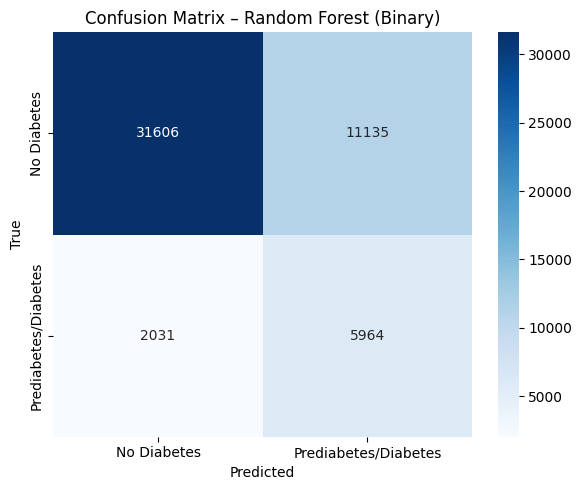


Top 15 feature importances:
GenHlth                 0.214270
HighBP                  0.178877
BMI_winsorised          0.149961
Age                     0.111840
HighChol                0.085582
Income                  0.044127
DiffWalk                0.042807
PhysHlth                0.040593
HeartDiseaseorAttack    0.022892
Education               0.020479
MentHlth                0.018176
Sex                     0.012761
PhysActivity            0.011353
Smoker                  0.010054
Fruits                  0.009378
dtype: float64


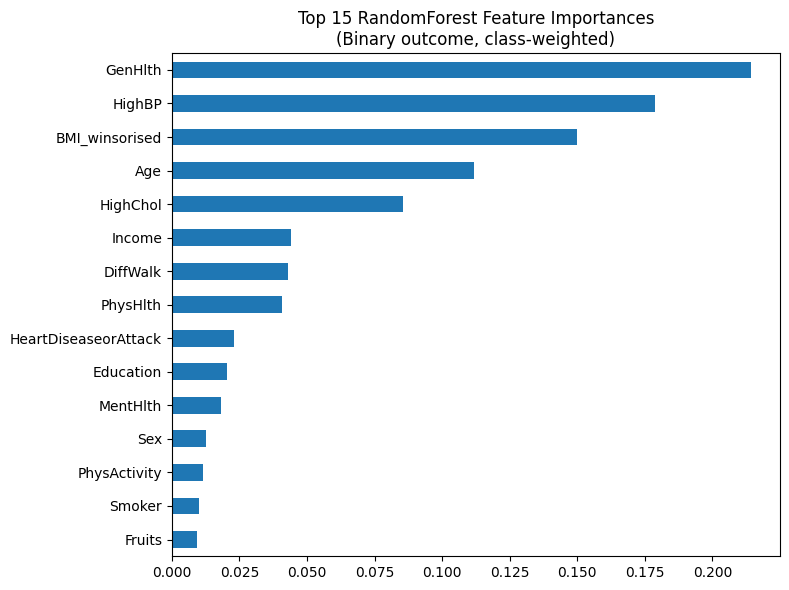


Feature importances saved to rf_binary_class_weight_feature_importances.csv


In [17]:
# RandomForest (binary) using class-weighted learning from above. Binary classificaiton of diabetes
# 0 = No diabetes, 1 = Pre-diabetes + Diabetes
# Findings
# The model achieved 74% accuracy. Once again, the model was strong at identifying individuals without diabetes while still capturing the most at risk cases despite 
# the class imbalance. Feature importance results highlight that overall health status, blood pressure and BMI are the dominant predictors for diabetes.
# Confusion Matrix analysis shows that:
# Recall is the most important metric in this diagnostic setting, and it is strong and similar for both classes (i.e. no diabetes and prediabetes/diabetes), 
# with the model identifying circa 75% of cases. 
# However, the precision is not so good as 11,135 healthy individuals are incorrectly flagged as having a diabetes risk. Equally, 2,031 individuals who have pre/diabetes 
# are incorrectly flagged as no diabetes. 
# This means in a real-world setting, the model may be useful for initial screening, but it is not reliable for confirming a formal prediabetes or diabetes diagnosis.


# Code generated via ChatGPT and modified by analyst

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
)

# Prepare features & binary target
X = df.select_dtypes(include=["number"]).copy()

# Drop target
X = X.drop(columns=["Diabetes_012"])

# Drop raw BMI and BMI category code, keep BMI_winsorised
cols_to_drop = ["BMI", "BMI_Category_Code"]
X = X.drop(columns=[c for c in cols_to_drop if c in X.columns])

# Binary target: 1 = prediabetes or diabetes, 0 = no diabetes
y = (df["Diabetes_012"] > 0).astype(int)
print("Binary class distribution (0=No Diabetes, 1=Prediabetes/Diabetes):")
print(y.value_counts())

# -----------------------
# Train/test split (stratified)
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nClass distribution (train):", Counter(y_train))
print("Class distribution (test):", Counter(y_test))

# -----------------------
# RandomForest classifier (class-weighted, no resampling)
# -----------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)

print("\nTraining RandomForest with class-weighted learning (no SMOTE)...")
rf.fit(X_train, y_train)

# -----------------------------------------
# Metrics
# -----------------------------------------
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Diabetes', 'Prediabetes/Diabetes'],
    yticklabels=['No Diabetes', 'Prediabetes/Diabetes']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – Random Forest (Binary)')
plt.tight_layout()
plt.show()

# -----------------------
# Feature importances
# -----------------------
fi = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 15 feature importances:")
print(fi.head(15))

# Optional plot
plt.figure(figsize=(8, 6))
fi.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 RandomForest Feature Importances\n(Binary outcome, class-weighted)")
plt.tight_layout()
plt.show()

# Optional: save feature importances for Power BI
fi.to_csv("rf_binary_class_weight_feature_importances.csv", header=["importance"])
print("\nFeature importances saved to rf_binary_class_weight_feature_importances.csv")

Clinical / Physiological    66.96
Demographic                 12.80
Functional Health           10.44
Socioeconomic                6.64
Lifestyle                    3.16
dtype: float64


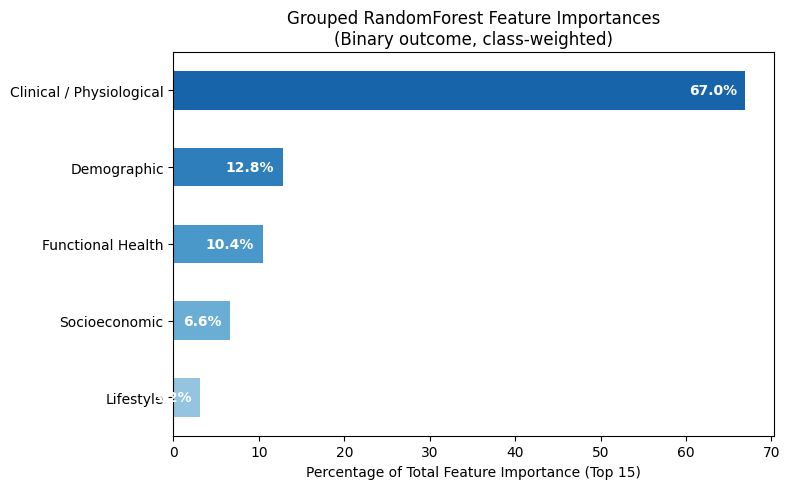

Saved grouped feature importances to CSV


In [18]:
# Grouping the existing top 15 features into health and lifestyle categories to add to the story
# AI generated code modified by data analyst
# -----------------------
# Group feature importances
# -----------------------

feature_groups = {
    "Clinical / Physiological": [
        "GenHlth",
        "HighBP",
        "BMI_winsorised",
        "HighChol",
        "HeartDiseaseorAttack",
    ],
    "Demographic": [
        "Age",
        "Sex",
    ],
    "Functional Health": [
        "DiffWalk",
        "PhysHlth",
        "MentHlth",
    ],
    "Socioeconomic": [
        "Income",
        "Education",
    ],
    "Lifestyle": [
        "Smoker",
        "Fruits",
        "PhysActivity"
         ],
}
# -----------------------
# Aggregate feature importances by group
# -----------------------

grouped_importance = {}

for group, features in feature_groups.items():
    grouped_importance[group] = fi.loc[
        fi.index.intersection(features)
    ].sum()

grouped_fi = pd.Series(grouped_importance).sort_values(ascending=False)
grouped_fi_pct = grouped_fi / grouped_fi.sum() * 100

print(grouped_fi_pct.round(2))

import matplotlib.pyplot as plt
import numpy as np

# Sort values for plotting
sorted_fi = grouped_fi_pct.sort_values()

plt.figure(figsize=(8, 5))

# Create a gradient: lighter to darker blue
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(sorted_fi)))

ax = sorted_fi.plot(kind="barh", color=colors)

# Add % labels inside the bars
for i, v in enumerate(sorted_fi):
    ax.text(v - 1, i, f"{v:.1f}%", va='center', ha='right', color='white', fontweight='bold')

plt.xlabel("Percentage of Total Feature Importance (Top 15)")
plt.title("Grouped RandomForest Feature Importances\n(Binary outcome, class-weighted)")
plt.tight_layout()
plt.show()

grouped_fi_pct.to_csv(
    "rf_grouped_binary_random_forest_feature_importances.csv",
    header=["percentage_importance"]
)

print("Saved grouped feature importances to CSV")

Data loaded: (253680, 24)

Features included:
Index(['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'BMI_winsorised'], dtype='object')

Binary class distribution:
Diabetes_012
0    213703
1     39977
Name: count, dtype: int64

Train/test shapes: (202944, 21) (50736, 21)

Fitting RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}

Classification Report:
              precision    recall  f1-score   support

           0     0.9084    0.8526    0.8796     42741
           1     0.4067    0.5403    0.4641      7995

    accuracy                         0.8034     50736
   macro avg     0.6575    0.6964

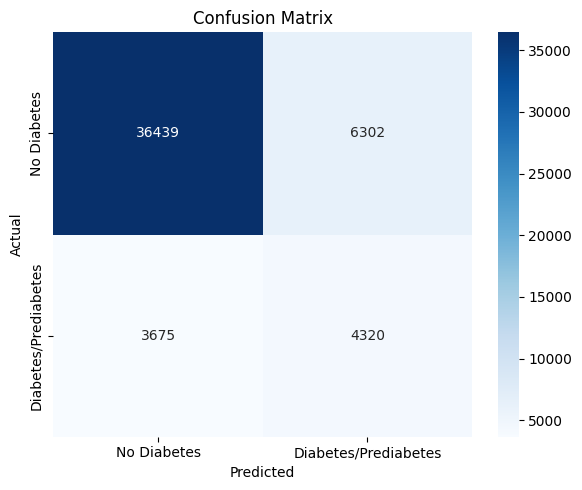


All Feature Importances (sorted):
BMI_winsorised: 0.156779
GenHlth: 0.145500
Age: 0.117952
HighBP: 0.107613
Income: 0.068414
PhysHlth: 0.064184
HighChol: 0.057104
MentHlth: 0.048144
Education: 0.043550
DiffWalk: 0.030598
Smoker: 0.021375
Fruits: 0.021355
Sex: 0.020849
HeartDiseaseorAttack: 0.019409
PhysActivity: 0.019118
Veggies: 0.017157
NoDocbcCost: 0.010246
HvyAlcoholConsump: 0.009233
Stroke: 0.007801
CholCheck: 0.007309
AnyHealthcare: 0.006308


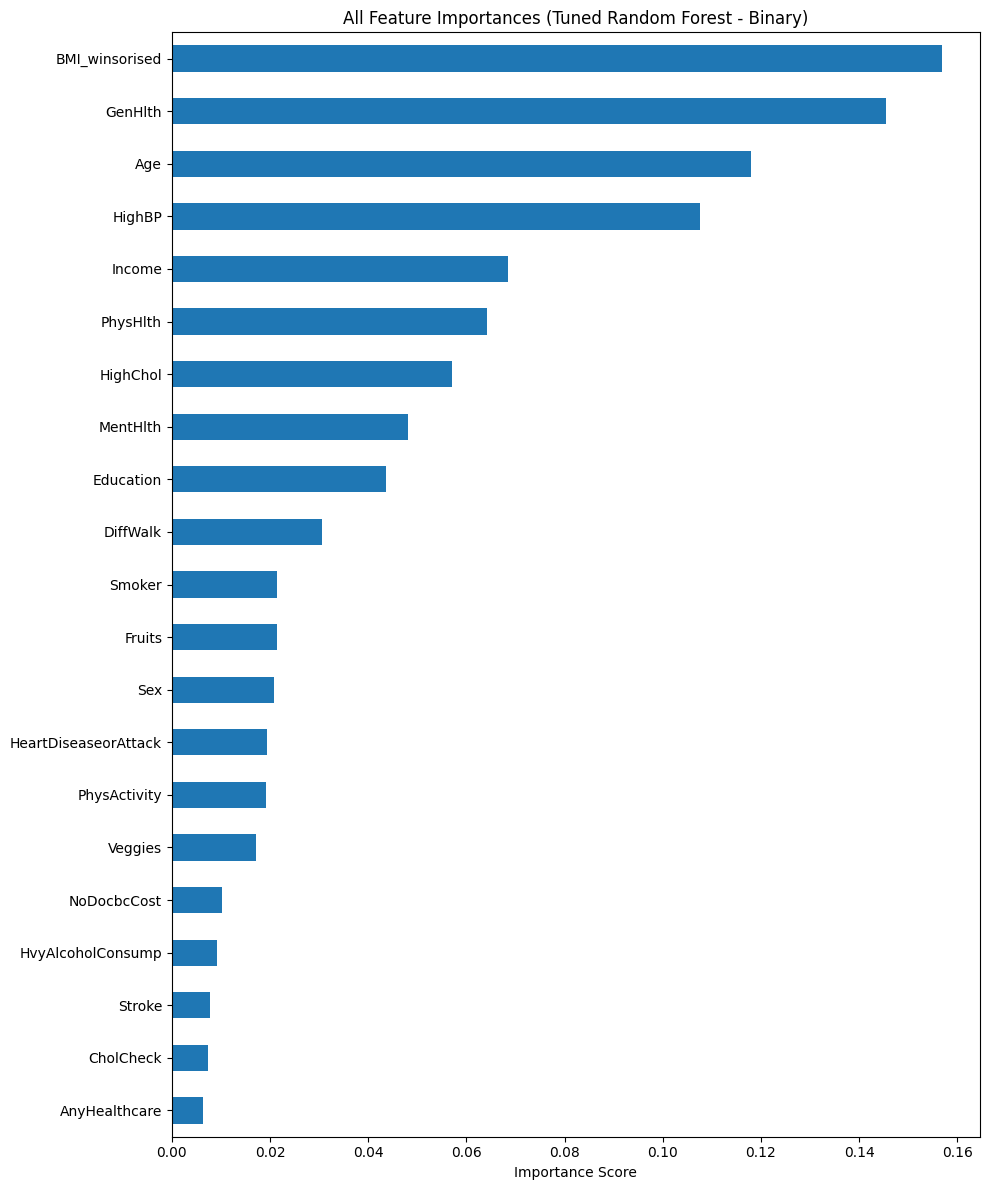


Computing SHAP values using PermutationExplainer (super fast)...


PermutationExplainer explainer: 301it [16:41,  3.34s/it]                         
C:\Users\teres\AppData\Local\Temp\ipykernel_2432\2196466177.py:165: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[..., 1], sample, show=False)


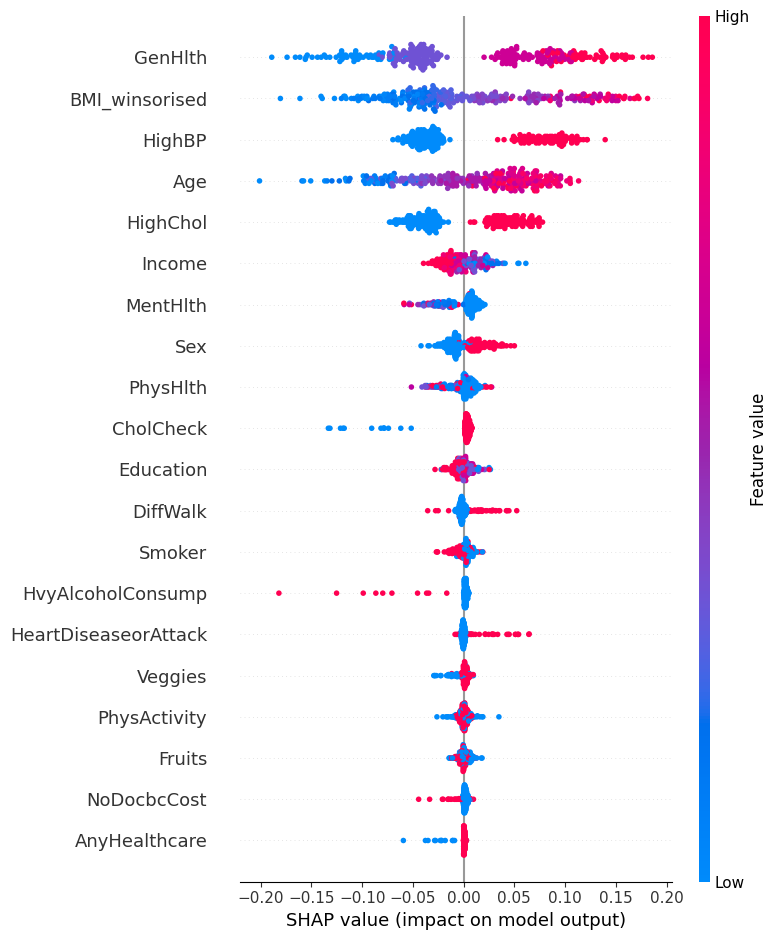

In [19]:
# Hyperparameter Tuning for Binary Random Forest (No Diabetes vs. Diabetes/Prediabetes)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

# ---------------------------------------------------------
# 1. Load dataset
# ---------------------------------------------------------
df = pd.read_csv("diabetes_bmi_winsorised.csv")
print("Data loaded:", df.shape)

# ---------------------------------------------------------
# 2. Prepare features & binary target
# ---------------------------------------------------------
X = df.select_dtypes(include=["number"]).copy()

# Drop target
X = X.drop(columns=["Diabetes_012"])

# Drop raw BMI and BMI category code, keep BMI_winsorised
cols_to_drop = ["BMI", "BMI_Category_Code"]
X = X.drop(columns=[c for c in cols_to_drop if c in X.columns])

print("\nFeatures included:")
print(X.columns)

# Binary target: 1 = diabetes or prediabetes, 0 = no diabetes
y = (df["Diabetes_012"] > 0).astype(int)

print("\nBinary class distribution:")
print(y.value_counts())

# ---------------------------------------------------------
# 3. Train/test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nTrain/test shapes:", X_train.shape, X_test.shape)

# ---------------------------------------------------------
# 4. RandomizedSearchCV parameter grid
# ---------------------------------------------------------
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'class_weight': ['balanced']
}

# ---------------------------------------------------------
# 5. Define model
# ---------------------------------------------------------
rf = RandomForestClassifier(random_state=42)

# ---------------------------------------------------------
# 6. Define RandomizedSearchCV
# ---------------------------------------------------------
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)

# ---------------------------------------------------------
# 7. Fit the model
# ---------------------------------------------------------
print("\nFitting RandomizedSearchCV...")
rf_random.fit(X_train, y_train)

# ---------------------------------------------------------
# 8. Evaluate model
# ---------------------------------------------------------
print("\nBest Parameters:", rf_random.best_params_)

best_rf = rf_random.best_estimator_
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual_NoDiabetes", "Actual_Diabetes"],
    columns=["Pred_NoDiabetes", "Pred_Diabetes"]
)

print("\nConfusion Matrix (labeled):")
print(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes/Prediabetes"],
            yticklabels=["No Diabetes", "Diabetes/Prediabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 9. Feature Importances
# ---------------------------------------------------------
fi = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nAll Feature Importances (sorted):")
for feature, importance in fi.items():
    print(f"{feature}: {importance:.6f}")

plt.figure(figsize=(10, 12))
fi.sort_values().plot(kind='barh')
plt.title('All Feature Importances (Tuned Random Forest - Binary)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Save feature importances to a CSV for Power BI
fi_df = fi.reset_index()
fi_df.columns = ["feature", "importance"]
fi_df.to_csv("final_model_feature_importances_sorted.csv", index=False)


# ---------------------------------------------------------
# 10. SHAP Explainability
# ---------------------------------------------------------
print("\nComputing SHAP values using PermutationExplainer (super fast)...")

shap.initjs()

sample = X_test.sample(300, random_state=42)

explainer = shap.PermutationExplainer(best_rf.predict_proba, sample)
shap_values = explainer(sample)

plt.figure(figsize=(12, 20))
shap.summary_plot(shap_values.values[..., 1], sample, show=False)
plt.savefig("shap_summary_all_features.png", dpi=300, bbox_inches='tight')
plt.show()


Clinical / Physiological    50.15
Functional Health           14.29
Demographic                 13.88
Socioeconomic               12.85
Lifestyle                    8.82
dtype: float64


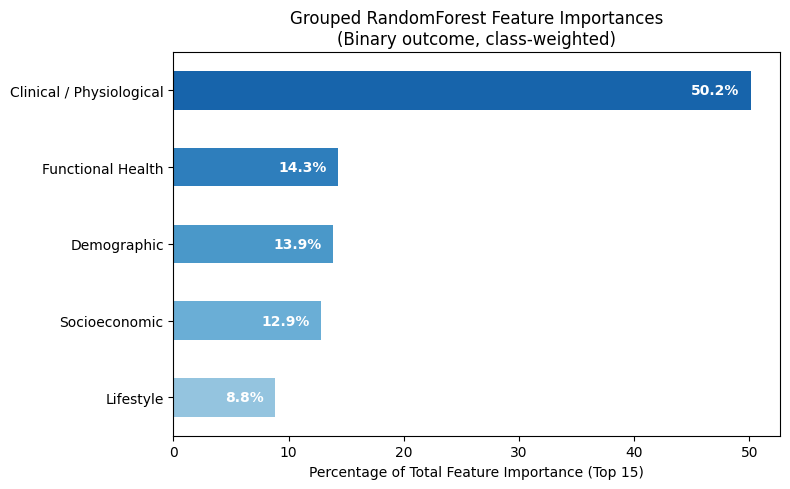

In [20]:
# Finally grouping the existing features into health and lifestyle categories to add to the story
# AI generated code modified by data analyst

# -----------------------
# Group feature importances
# -----------------------

feature_groups = {
    "Clinical / Physiological": [
        "GenHlth",
        "HighBP",
        "BMI_winsorised",
        "HighChol",
        "HeartDiseaseorAttack",
        "CholCheck",
        "Stroke",
    ],
    "Demographic": [
        "Age",
        "Sex",
    ],
    "Functional Health": [
        "DiffWalk",
        "PhysHlth",
        "MentHlth",
    ],
    "Socioeconomic": [
        "Income",
        "Education",
        "NoDocbcCost",
        "AnyHealthcare"
    ],
    "Lifestyle": [
        "Smoker",
        "Fruits",
        "PhysActivity",
        "HvyAlcoholConsump",
        "Veggies"
    ],
}

# -----------------------
# Aggregate feature importances by group
# -----------------------

grouped_importance = {}

for group, features in feature_groups.items():
    grouped_importance[group] = fi.loc[
        fi.index.intersection(features)
    ].sum()

grouped_fi = pd.Series(grouped_importance).sort_values(ascending=False)
grouped_fi_pct = grouped_fi / grouped_fi.sum() * 100

print(grouped_fi_pct.round(2))

import matplotlib.pyplot as plt
import numpy as np

# Sort values for plotting
sorted_fi = grouped_fi_pct.sort_values()

plt.figure(figsize=(8, 5))

# Create a gradient: lighter to darker blue
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(sorted_fi)))

ax = sorted_fi.plot(kind="barh", color=colors)

# Add % labels inside the bars
for i, v in enumerate(sorted_fi):
    ax.text(v - 1, i, f"{v:.1f}%", va='center', ha='right', color='white', fontweight='bold')

plt.xlabel("Percentage of Total Feature Importance (Top 15)")
plt.title("Grouped RandomForest Feature Importances\n(Binary outcome, class-weighted)")
plt.tight_layout()
plt.show()

# -----------------------
# Save grouped importances (binary, post-tuning)
# -----------------------

grouped_fi_pct.to_csv(
    "final_model_grouped_binary_random_forest_hyperparameter_feature_importances.csv",
    header=["percentage_importance"]
)


